# 13 — Dijkstra's Algorithm on an Occupancy Grid

**Section:** Motion Planning · **Mirrors MATLAB:** *Motion Planners (RRT, PRM, Hybrid A\*)* — Dijkstra baseline

Dijkstra is A\* with a zero heuristic: it explores cells in pure cost-to-come order. This guarantees optimality but expands more nodes than A\* (which uses the goal-distance heuristic to bias exploration).

Comparing the two on the same map helps illustrate why an admissible heuristic matters.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import heapq

np.random.seed(42)

H, W = 30, 50
grid = np.zeros((H, W), dtype=np.uint8)
for _ in range(40):
    y, x = np.random.randint(2, H - 3), np.random.randint(2, W - 3)
    grid[y - 1:y + 2, x - 1:x + 2] = 1
start, goal = (2, 2), (H - 3, W - 3)
grid[start] = 0; grid[goal] = 0


In [2]:
def dijkstra(grid, start, goal):
    H, W = grid.shape
    heap = [(0.0, start, None)]
    came_from, dist = {}, {start: 0.0}
    nbrs = [(-1, 0), (1, 0), (0, -1), (0, 1),
            (-1, -1), (-1, 1), (1, -1), (1, 1)]
    while heap:
        d, current, parent = heapq.heappop(heap)
        if current in came_from:
            continue
        came_from[current] = parent
        if current == goal:
            path = []
            while current is not None:
                path.append(current); current = came_from[current]
            return path[::-1], dist
        for dy, dx in nbrs:
            ny, nx = current[0] + dy, current[1] + dx
            if 0 <= ny < H and 0 <= nx < W and grid[ny, nx] == 0:
                nd = d + np.hypot(dy, dx)
                if nd < dist.get((ny, nx), np.inf):
                    dist[(ny, nx)] = nd
                    heapq.heappush(heap, (nd, (ny, nx), current))
    return None, dist


path, dist = dijkstra(grid, start, goal)
print(f"Path: {len(path)} cells   expanded: {len(dist)} cells")


Path: 47 cells   expanded: 1190 cells


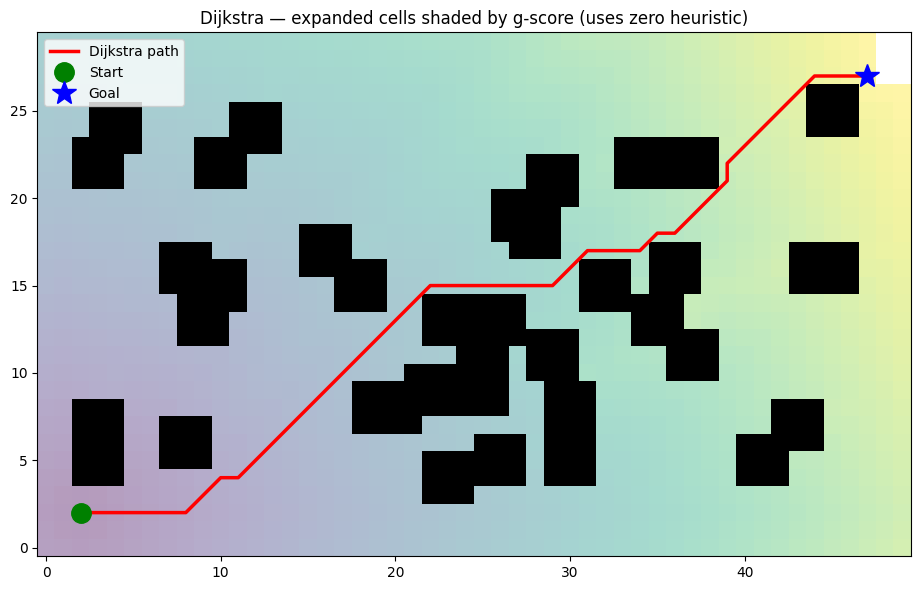

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.imshow(grid, cmap='Greys', origin='lower')
expanded = np.full_like(grid, np.nan, dtype=float)
for (y, x), c in dist.items():
    expanded[y, x] = c
ax.imshow(expanded, cmap='viridis', alpha=0.4, origin='lower')

ys, xs = zip(*path)
ax.plot(xs, ys, 'r-', lw=2.5, label='Dijkstra path')
ax.plot(start[1], start[0], 'go', ms=14, label='Start')
ax.plot(goal[1], goal[0], 'b*', ms=18, label='Goal')
ax.legend(); ax.set_title("Dijkstra — expanded cells shaded by g-score (uses zero heuristic)")
plt.tight_layout()
plt.show()
